In [ ]:
#23070521122,Rushi Parhad
# 1. Load the MNIST Dataset and Preprocess It

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape the data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [ ]:
# 2. Build Encoder-Decoder Architecture

# Encoder
encoder_input = layers.Input(shape=(28, 28, 1), name='encoder_input')
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # Output 14x14
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # Output 7x7
encoded = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='encoder_output_conv')(x) # Latent space will be 7x7x128

# Encoder Model
encoder = models.Model(encoder_input, encoded, name='encoder')

# Decoder
# The input shape for the decoder now matches the encoder's output shape
decoder_input_for_submodel = layers.Input(shape=(7, 7, 128), name='decoder_input')
x_decoder = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(decoder_input_for_submodel)
x_decoder = layers.UpSampling2D((2, 2))(x_decoder) # Now 14x14
x_decoder = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x_decoder)
x_decoder = layers.UpSampling2D((2, 2))(x_decoder) # Now 28x28
decoded_output_for_submodel = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoder_output')(x_decoder)

# Decoder Model
decoder = models.Model(decoder_input_for_submodel, decoded_output_for_submodel, name='decoder')

# Autoencoder Model: chain encoder and decoder
autoencoder_output = decoder(encoder(encoder_input))
autoencoder = models.Model(encoder_input, autoencoder_output, name='autoencoder')

autoencoder.summary()
encoder.summary()
decoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 7, 7, 128)      │        92,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       221,953 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,625 (1.20 MB)

 Trainable params: 314,625 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,953 (867.00 KB)

 Trainable params: 221,953 (867.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Autoencoder

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 418s 886ms/step - loss: 0.0897 - val_loss: 0.0720
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 431s 864ms/step - loss: 0.0702 - val_loss: 0.0680
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 447s 876ms/step - loss: 0.0678 - val_loss: 0.0664
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 410s 874ms/step - loss: 0.0666 - val_loss: 0.0656
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 444s 878ms/step - loss: 0.0658 - val_loss: 0.0650


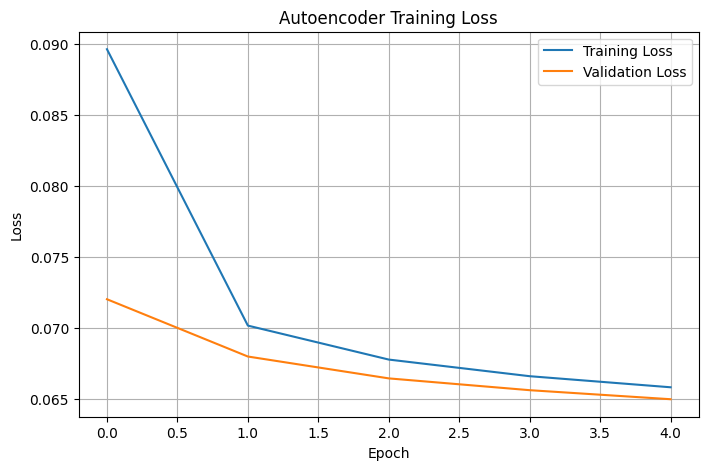

In [ ]:
# 3. Train the Autoencoder

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

history = autoencoder.fit(
    x_train, x_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Plot training history
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Compare Original and Reconstructed Images

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step


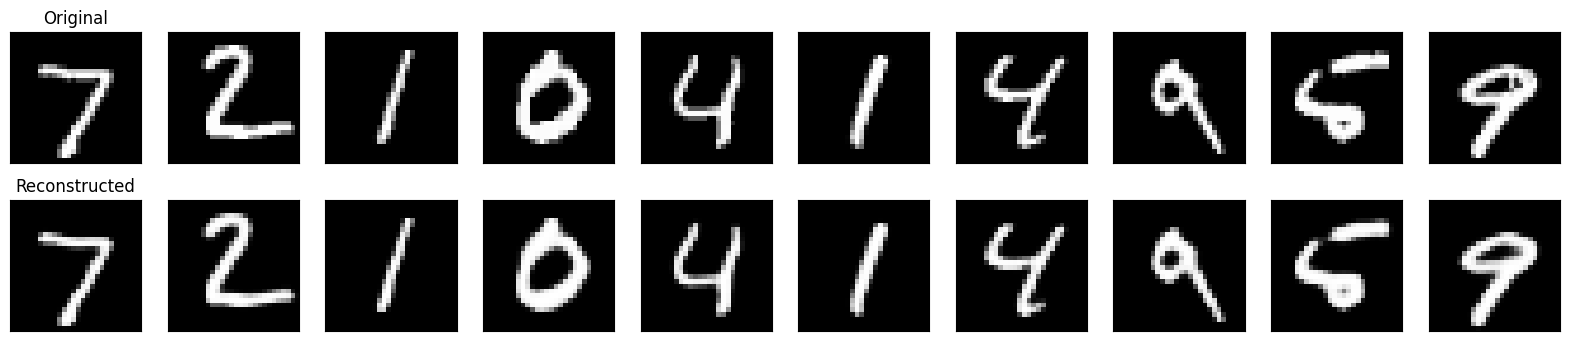

In [ ]:
# 4. Compare Original and Reconstructed Images

# Get reconstructed images from the test set
reconstructed_images = autoencoder.predict(x_test)

# Display original and reconstructed images
n = 10  # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title('Original')

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title('Reconstructed')
plt.show()